In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np

In [2]:
def radial_mask(r, cx=128, cy=128, sx=np.arange(0, 256), sy=np.arange(0, 256), delta=1):
    ind = (sx[np.newaxis, :] - cx) ** 2 + (sy[:, np.newaxis] - cy) ** 2
    ind1 = ind <= ((r[0] + delta) ** 2)  # one liner for this and below?
    ind2 = ind > (r[0] ** 2)
    return ind1 * ind2


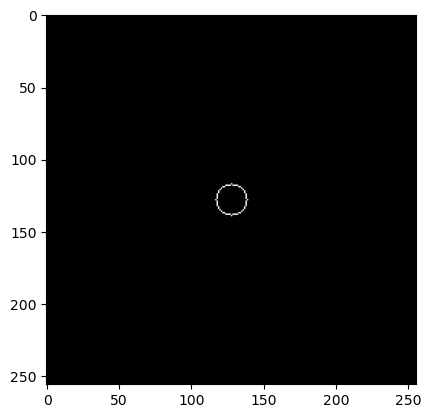

In [3]:
# Ejemplo de uso:
r = np.array([10])  # Radio del anillo
mask = radial_mask(r)

# SHow radial mask
plt.imshow(mask, cmap='gray')
plt.show()

In [4]:
def get_radial_masks(width, height):
    freq_nyq = int(np.floor(int(min(width, height)) / 2.0))
    
    radii = np.arange(128).reshape(128, 1)  # image size 256
    
    radial_masks = np.apply_along_axis(radial_mask, 1, radii, 128, 128, np.arange(0, 256), np.arange(0, 256), 1)
    radial_masks = np.expand_dims(radial_masks, 1)
    radial_masks = np.expand_dims(radial_masks, 1)

    spatial_freq = radii.astype(np.float32) / freq_nyq
    spatial_freq = spatial_freq / max(spatial_freq)

    return radial_masks, spatial_freq


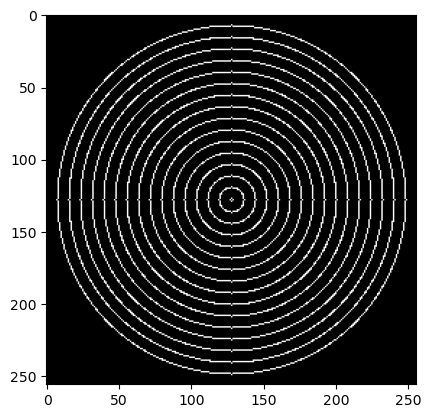

In [5]:

#Show radial masks

radial_masks, _ = get_radial_masks(256,256)

radial_masks = radial_masks.squeeze((1,2))

combined_image = np.zeros(radial_masks.shape[1:])  # Crear una matriz de ceros con las mismas dimensiones que las imágenes

# Iterar sobre las máscaras radiales y superponerlas en la imagen combinada
for i in range(0, radial_masks.shape[0], 8):
    array_2d = radial_masks[i, :, :]
    combined_image += array_2d  # Sumar cada máscara al conjunto

# Mostrar la imagen combinada
plt.imshow(combined_image, cmap='gray')
plt.show()


In [6]:

def get_set_fourier_ring_correlations(image1, image2):
    # Transform tensor to complex
    image1 = image1.to(torch.complex64)
    image2 = image2.to(torch.complex64)
    
    image1 = image1.unsqueeze(0).repeat(128, 1, 1)
    image2 = image2.unsqueeze(0).repeat(128, 1, 1)

    radial_masks, spatial_frecuency = get_radial_masks(256,256)
    radial_masks = radial_masks.squeeze((1,2))

    spatial_frecuency = torch.from_numpy(spatial_frecuency.squeeze(1))

    radial_masks = torch.from_numpy(radial_masks)
    
    radial_masks = radial_masks.to(torch.complex64)
     
    
    # Compute fourier transform
    fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1))
    fft_image2 = torch.fft.fftshift(torch.fft.fft2(image2))

    # Get elements only in the ring
    t1 = fft_image1 * radial_masks
    t2 = fft_image2 * radial_masks
        
    # image2 complex conjugate
    t2_conj = t2.conj()

    # Numerator
    numerador = torch.real((t1 * t2_conj).sum(dim=(1,2)))

    # Denominator    
    denominador_1 = ((torch.abs(t1) * torch.abs(t1)).sum(dim=(1,2)))
    denominador_2 = ((torch.abs(t2) * torch.abs(t2)).sum(dim=(1,2)))     
    denominador = torch.sqrt(denominador_1 * denominador_2)
   

    # Fourier shell correlation
    FRC = torch.div(numerador, denominador)

    FRC = torch.where(torch.isinf(FRC), torch.zeros_like(FRC), FRC)  # inf
    FRC = torch.where(torch.isnan(FRC), torch.zeros_like(FRC), FRC)  # nan

    return FRC , spatial_frecuency


In [27]:
def fourier_ring_correlation(FRC, spatial_frecuency):

    FRC = FRC.numpy()
    spatial_frecuency = spatial_frecuency.numpy()
      

    area = np.trapz(FRC, spatial_frecuency)
    
    return area

In [28]:


FSC, spatial_frecuency = get_set_fourier_ring_correlations(image1, image1)
fourier_ring_correlation(FSC, spatial_frecuency)

1.0

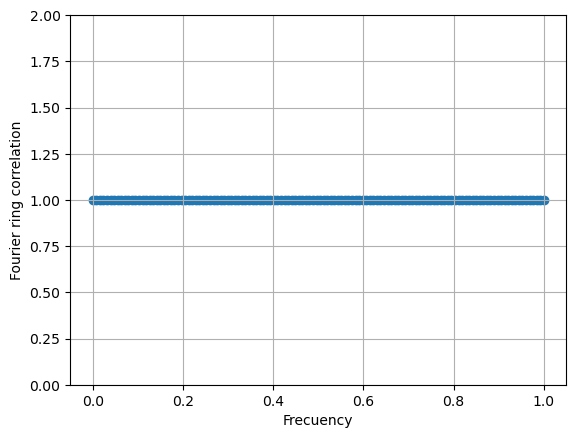

In [22]:

image1 = torch.randn(256, 256)
image2 = torch.randn(256, 256)


FSC, spatial_frecuency = get_set_fourier_ring_correlations(image1, image1)


x = spatial_frecuency.numpy()
y = FSC.numpy()

# Crear un gráfico de dispersión
plt.scatter(x, y)
#plt.scatter(x,np.sin(x))
plt.xlabel('Frecuency')
plt.ylabel('Fourier ring correlation')
plt.ylim(0, 100)
plt.grid(True)
plt.ylim(0, 2);


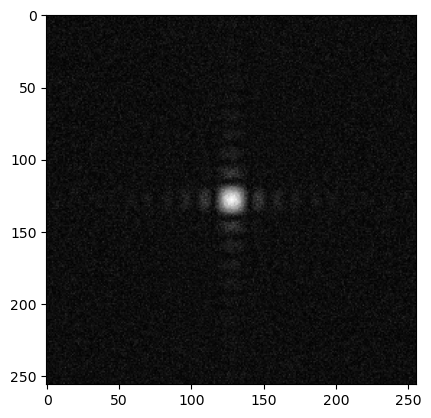

(tensor([ 9.9301e-01,  9.9808e-01,  9.9704e-01,  9.9319e-01,  9.9181e-01,
         9.9256e-01,  9.9097e-01,  9.8871e-01,  9.8330e-01,  9.7184e-01,
         9.3965e-01,  8.9412e-01,  7.1424e-01,  3.9804e-01,  5.2265e-01,
         6.4295e-01,  7.3099e-01,  8.1845e-01,  8.1280e-01,  7.6302e-01,
         7.9400e-01,  6.9694e-01,  6.8210e-01,  4.6042e-01,  3.4553e-01,
        -2.2828e-02,  2.4382e-01,  6.7398e-03,  3.5316e-01,  3.3347e-01,
         5.6452e-01,  4.2394e-01,  5.2028e-01,  4.4656e-01,  3.5232e-01,
         4.6171e-01,  1.7402e-01,  1.2160e-01, -2.9477e-02,  8.6563e-02,
         1.4159e-01,  1.3349e-01,  2.8416e-01,  2.8046e-01,  3.8226e-01,
         3.2937e-01,  2.4799e-01,  2.3688e-01,  1.7011e-01,  1.0281e-01,
        -6.3193e-02, -2.6065e-02,  1.7428e-02,  1.1871e-01,  1.2562e-01,
         1.7794e-01,  1.9981e-01,  1.9187e-01,  1.1364e-01,  1.5774e-01,
         1.0165e-01,  3.8291e-02,  2.8577e-02,  1.0591e-02,  5.5353e-02,
        -2.0544e-02,  4.6320e-02,  7.3504e-02,  1.

In [14]:


image1 = torch.randn(256, 256)
image1[:20,:20] = 10

fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1.to(torch.complex64)))

tensor_numpy = np.abs(fft_image1.numpy())

# Mostrar el arreglo usando Matplotlib
plt.imshow(tensor_numpy, cmap='gray')
plt.show()

image2 = torch.randn(256, 256)
image2[:20,:20] = 10
print(get_set_fourier_ring_correlations(image1, image2))



In [17]:
# def fourier_ring_correlation(image1, image2, rn, spatial_freq):
#     # Transponer las imágenes para que los canales estén primero
#     image1 = image1.permute(0, 3, 1, 2)
#     image2 = image2.permute(0, 3, 1, 2)
    
#     # Convertir a tipo de dato complejo
#     image1 = image1.to(torch.complex64)
#     image2 = image2.to(torch.complex64)
#     rn = rn.to(torch.complex64)
    
#     # Aplicar la transformada de Fourier 2D y centrar las frecuencias
#     fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1), dim=(2, 3))
#     fft_image2 = torch.fft.fftshift(torch.fft.fft2(image2), dim=(2, 3))

#     # Multiplicar en el dominio de la frecuencia (término a término)
#     t1 = fft_image1 * rn
#     t2 = fft_image2 * rn
    
#     # Calcular las correlaciones
#     c1 = torch.real(torch.sum(t1 * torch.conj(t2), dim=(2, 3, 4)))
#     c2 = torch.sum(torch.abs(t1) ** 2, dim=(2, 3, 4))
#     c3 = torch.sum(torch.abs(t2) ** 2, dim=(2, 3, 4))
    
#     # Calcular el FRC
#     frc = c1 / torch.sqrt(c2 * c3)
#     frc = torch.where(torch.isinf(frc), torch.zeros_like(frc), frc)  # inf
#     frc = torch.where(torch.isnan(frc), torch.zeros_like(frc), frc)  # nan

#     # Calcular la suma de Riemann
#     t = spatial_freq
#     y = frc
#     riemann_sum = torch.sum((t[1:] - t[:-1]) * (y[:-1] + y[1:]) / 2., dim=0)
    
#     return riemann_sum